# Bayesian linear mixture model

In [1]:
import geopandas as gpd
import numpy as np
from cmdstanpy import CmdStanModel
import os 
import arviz as az
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = gpd.read_file('updated_data.geojson')

selected_covariates = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman"]
X=df[selected_covariates].to_numpy()

# new_selected_covariates = ["coverage", "public_coverage","per_capita_public_expenditure","other_percapita_public_expenditure","other_percapita_user_contrib","ecec_diffusion","fertility_rate","GDP","young_neet", "internet_coverage_rate", "fem_house_rate"]
# new_selected_covariates = ["coverage", "public_coverage","per_capita_public_expenditure","other_percapita_public_expenditure","other_percapita_user_contrib","ecec_diffusion","GDP","young_neet", "internet_coverage_rate"]
# new_selected_covariates = ['fem_house_rate', 'n_members_family', 'net_migration_rate', 'avg_children_per_woman', 'fem_maj_empl_rate', 'coverage', 'public_coverage', 'per_capita_public_expenditure', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'ecec_diffusion']
# new_selected_covariates = ['n_members_family', 'net_migration_rate', 'avg_children_per_woman', 'fem_maj_empl_rate', 'coverage', 'public_coverage', 'per_capita_public_expenditure', 'other_percapita_public_expenditure', 'other_percapita_user_contrib', 'ecec_diffusion']
# X=df[new_selected_covariates].to_numpy()

# print(len(selected_covariates))



y=df["fem_empl_rate"].to_numpy()


Normalization and logit

In [3]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

y = y/100
y_scaled = np.log(y/(1-y)) 



## Computation of the proximity matrix W

In [4]:
n = len(df)
node1 = []
node2 = []
num_neighbors = np.zeros(n, dtype=int)

sindex = df.sindex  # spatial index

for i, geom in enumerate(df.geometry):
    # candidates using bounding boxes
    possible_matches = list(sindex.intersection(geom.bounds))

    for j in possible_matches:
        if j <= i:
            continue
        if geom.touches(df.geometry[j]):
            node1.append(i + 1)   # Stan is 1-based
            node2.append(j + 1)

            num_neighbors[i] += 1
            num_neighbors[j] += 1

node1 = np.asarray(node1, dtype=int)
node2 = np.asarray(node2, dtype=int)

W = np.zeros((n, n), dtype=int)

for i, j in zip(node1 - 1, node2 - 1):
    W[i, j] = 1
    W[j, i] = 1



Stan Model

In [5]:
str_model="""


functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of V
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}


data {
    // Data
    int N;
    int P;

    int K; //nb of clusters

    matrix[N, P] X;
    array[N] real y;

    //proximity matrix
    matrix[N, N] W;

    
    // Prior parameters
    array[4] real p0_params;
    real ai_dir; //in our model alpha=1 for dirichlet prior

    real tau20;
    real tau21;
}

transformed data {
    real a0 = p0_params[1];
    real b0 = p0_params[2];
    real sigma0 = p0_params[3];
    real sigma1 = p0_params[4];

        //Vectors needed for Car Prior
    vector[N] D;            // diagonal entries of D
    vector[N] lambda;       // eigenvalues of D-W
    for (i in 1:N)
        D[i] = sum(W[i]);     //sum of the colomns of W for one row i.
    lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {
    //array[K] real alpha;

    real alpha;
    matrix[K,P] beta; 

    array[K] real<lower=0.00001> sigma;

    simplex[K] weights;

    vector[N] phi;
    real<lower=0> tau2;
    real<lower=0 , upper=1> rho;
}

transformed parameters {
    matrix[N,K] mu;
    for(i in 1:N) {
        for(k in 1:K) {

            mu[i,k] = dot_product(row(X, i), beta[k]) + alpha;
        }
        
    }
}


model {

    vector[K] contributions;
    for (i in 1:N) {
        for(k in 1:K) {
            contributions[k] = log(weights[k]) + normal_lpdf(y[i] | mu[i,k] + phi[i], sigma[k]);
            // y[i] ~ normal(mu[i], sigma);  

            }
            target += log_sum_exp(contributions);
        }

        
    
    weights ~ dirichlet(rep_vector(ai_dir, K));

    for(k in 1:K) {
        //alpha[k] ~ normal(0, a0);

        for (j in 1:P) {
            beta[k,j] ~ normal(0, b0);
        }
        
        sigma[k] ~ inv_gamma(sigma0, sigma1);
        //sigma[k] ~ normal(0, 0.1);
        //sigma[k] ~ cauchy(0, 1);

        
    }
    alpha ~ normal(0, a0);

    phi ~ car_leroux(tau2, rho, W, D, lambda, N);
    tau2 ~ inv_gamma(tau20, tau21);
    rho ~ beta(2,2);
}

generated quantities {
    array[N] int cluster_allocs;
    for(i in 1:N){
        vector[K] log_probs = log(weights);
        for(k in 1:K) {
            log_probs[k] += normal_lpdf(y[i] | mu[i,k], sigma[k]);
        }
        cluster_allocs[i] = categorical_rng(softmax(log_probs))-1;
    }
}

"""


if not os.path.exists("./stan"):
    os.mkdir("./stan")
stan_file = "./stan/linear_model.stan"
with open(stan_file, "w") as f:
    print(str_model, file=f)

# Compile stan model
linear_model = CmdStanModel(stan_file=stan_file)

12:12:12 - cmdstanpy - INFO - compiling stan file /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model.stan to exe file /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model
12:12:33 - cmdstanpy - INFO - compiled model executable: /Users/paul/Documents/Polimi/bayesian_stat/projet/contrib_paul/models/stan/linear_model


In [21]:
K=5
N=len(y_scaled)
P=X.shape[1]
gmm_data = {
    "N": N,
    "P":P,
    "K":K,

    "X":X_scaled,
    "y": y_scaled,
    
    "W":W,

    "p0_params": np.array([1,1, 2, 1]),
    "ai_dir":1,
    "tau20":3,
    "tau21":2
}

# Algorithm parameters
algo_params = {
    "n_chains": 4,
    "n_burnin": 5000,
    "n_iter": 5000,
    "max_treedepth":12
}

# Sample
model = linear_model.sample(data=gmm_data, chains=algo_params["n_chains"], parallel_chains=algo_params["n_chains"],
                                  iter_warmup=algo_params["n_burnin"], iter_sampling=algo_params["n_iter"],max_treedepth=algo_params["max_treedepth"])

# control={"max_treedepth": algo_params["max_treedepth"]}
# Convert to arviz data type
chains = az.from_cmdstanpy(model)

12:22:57 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/10000 [00:00<?, ?it/s, (Warmup)]





chain 1:   2%|▏         | 200/10000 [00:11<07:45, 21.05it/s, (Warmup)]


chain 1:   3%|▎         | 300/10000 [00:11<04:45, 33.97it/s, (Warmup)]

chain 1:   4%|▍         | 400/10000 [00:12<03:20, 47.91it/s, (Warmup)]


chain 1:   5%|▌         | 500/10000 [00:13<02:41, 58.69it/s, (Warmup)]


chain 1:   6%|▌         | 600/10000 [00:14<02:19, 67.46it/s, (Warmup)]



chain 1:   7%|▋         | 700/10000 [00:16<02:13, 69.84it/s, (Warmup)]



chain 1:   8%|▊         | 800/10000 [00:17<02:02, 75.40it/s, (Warmup)]


chain 1:  10%|█         | 1000/10000 [00:19<01:48, 83.16it/s, (Warmup)]



chain 1:  11%|█         | 1100/10000 [00:20<01:42, 86.56it/s, (Warmup)]

chain 1:  12%|█▏        | 1200/10000 [00:21<01:31, 96.54it/s, (Warmup)]


chain 1:  14%|█▍        | 1400/10000 [00:22<01:12, 118.41it/s, (Warmup)]


chain 1:  15%|█▌        | 1500/10000 [00:23<01:05, 129.55it/s, (Warmup


12:24:29 - cmdstanpy - INFO - CmdStan done processing.


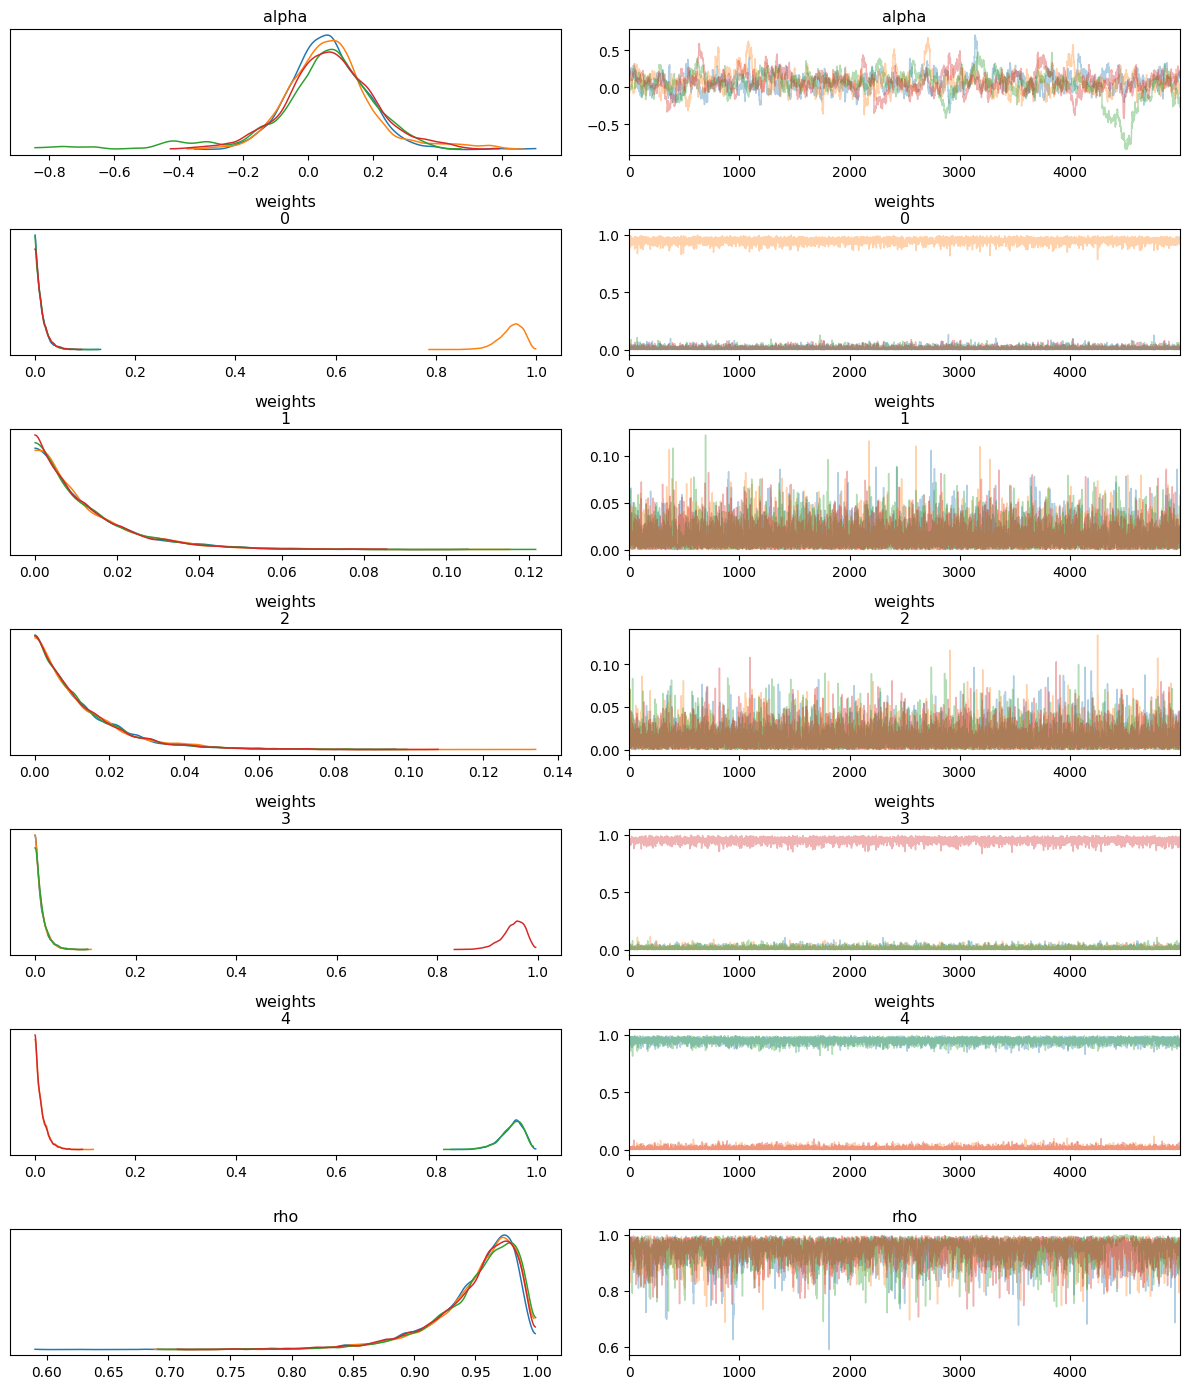

In [22]:
az.plot_trace(chains, var_names=["alpha","weights","rho"], compact=False)
plt.tight_layout()
plt.show()

## In this part, we want to assign y_i to a cluster (0,1,2)

In [23]:
# Function that computes the posterior similarity matrix
def get_psm(clus_alloc_chain):
    c_chain = np.vstack(clus_alloc_chain)
    out = np.zeros((c_chain.shape[1], c_chain.shape[1]))
    for i in range(c_chain.shape[1]):
        for j in range(i):
            out[i, j] = np.mean(c_chain[:, i] == c_chain[:, j])
    return out + out.T + np.eye(out.shape[0])



In [24]:
# Function that computes the cluster estimate that minimizes the binder loss function
def minbinder_sample(clus_alloc_chain, psm):
    losses = np.zeros(len(clus_alloc_chain))
    c_chain = np.vstack(clus_alloc_chain)
    for i in range(c_chain.shape[1]):
        for j in range(i):
            losses += (np.mean(c_chain[:, i] == c_chain[:, j]) - psm[i, j]) ** 2
    best_iter = np.argmin(losses)
    return clus_alloc_chain[best_iter]

In [25]:
print(chains.posterior.cluster_allocs.shape)

(4, 5000, 107)


In [26]:
# Retrieve cluster allocation variables
clust_allocs_chain = np.vstack(chains.posterior.cluster_allocs)

In [27]:
# Compute posterior similarity matrix
psm = get_psm(clust_allocs_chain)
psm.shape

(107, 107)

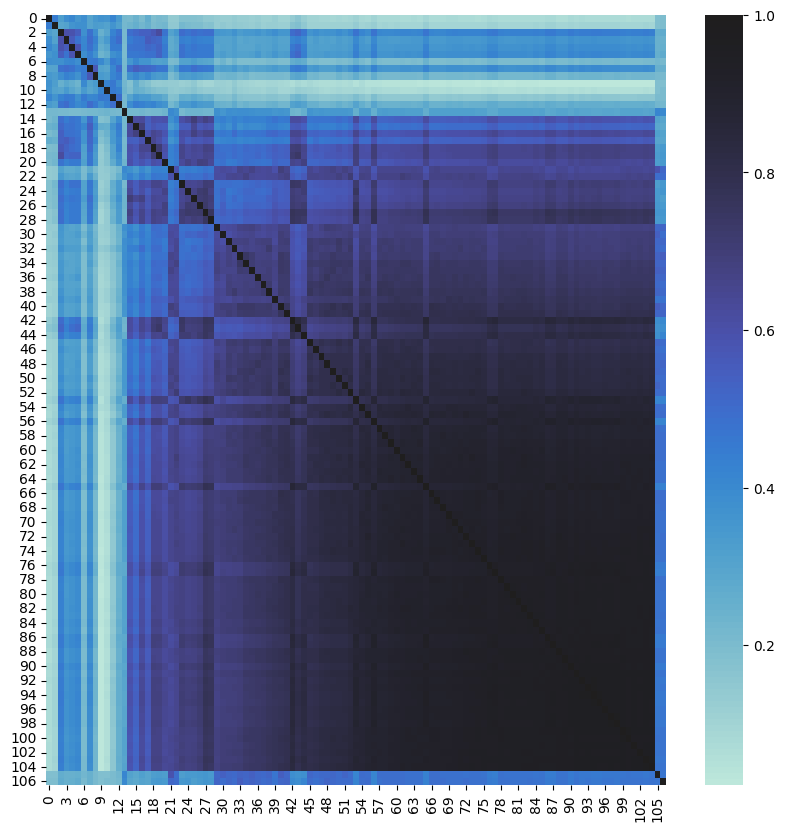

In [28]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
import seaborn as sns

def order_by_hclust(psm, method="average"):
    # convert similarity -> distance
    D = 1.0 - psm
    np.fill_diagonal(D, 0.0)
    D = np.clip(D, 0.0, 1.0)

    # linkage needs condensed distances
    condensed = squareform(D, checks=False)
    Z = linkage(condensed, method=method)
    order = leaves_list(Z)   # permutation of 0..N-1
    return order

order = order_by_hclust(psm)
psm_sorted = psm[np.ix_(order, order)]

plt.figure(figsize=(10,10))
sns.heatmap(psm_sorted, center=1)
plt.show()



In [29]:
# Compute point estimate of the cluster
best_clus = minbinder_sample(clust_allocs_chain, psm)

## Visualization of the results

[4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 3. 2. 4. 4. 4. 4.
 4. 4. 4. 4. 4. 4. 3. 4. 3. 0. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 3. 4. 4.
 4. 4. 4. 4. 4. 4. 4. 4. 0. 4. 4. 4. 4. 2. 4. 4. 4. 4. 4. 4. 3. 4. 4. 4.
 4. 4. 4. 4. 2. 4. 0. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4.
 4. 4. 4. 4. 3. 4. 4. 4. 3. 4. 4.]


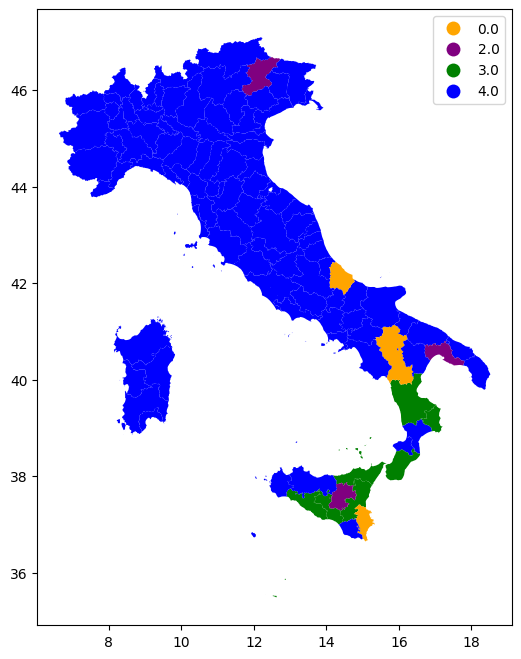

In [32]:
from matplotlib.colors import ListedColormap

# Plot the point cluster estimate on the empirical density histogram
# plt.hist(data, density=True, alpha=0.3)


color_map = {
    0: "red",      # couleur1
    1: "blue",     # couleur2
    2: "green"     # etc.
}

print(best_clus)


df["cluster_bayes"] = best_clus


# df.plot(column="cluster_bayes", categorical=True, legend=True)
cmap = ListedColormap(["blue", "green","red"])
# cmap = ListedColormap(["green", "red","blue"])
cmap = ListedColormap(["orange", "purple", "red", "green", "blue"])
# cmap = ListedColormap(["purple", "red", "green", "blue", "orange"])



ax = df.plot(
    column="cluster_bayes",
    categorical=True,
    cmap=cmap,
    legend=True,
    figsize=(8, 8)
)

plt.show()



In [31]:
print("model.summary",model.summary()[:20])


model.summary                  Mean      MCSE     StdDev        MAD          5%         50%  \
lp__       164.538000  0.255627  14.299100  14.441800  140.897000  164.780000   
alpha        0.059033  0.012417   0.148302   0.117598   -0.159635    0.062331   
beta[1,1]    0.019722  0.007108   0.843678   0.621015   -1.460510    0.083492   
beta[1,2]    0.020376  0.006884   0.844930   0.637923   -1.464860    0.073415   
beta[1,3]   -0.013697  0.006871   0.853020   0.619072   -1.459620   -0.059790   
beta[1,4]    0.006754  0.006728   0.829373   0.617922   -1.449000    0.030748   
beta[1,5]   -0.006648  0.006933   0.856271   0.637403   -1.492950   -0.010073   
beta[1,6]   -0.006487  0.006584   0.856623   0.624556   -1.479850   -0.045604   
beta[1,7]   -0.001228  0.006785   0.857345   0.624940   -1.480980    0.009397   
beta[1,8]   -0.041181  0.007149   0.844606   0.628656   -1.492410   -0.100054   
beta[1,9]   -0.003671  0.006864   0.849434   0.619916   -1.468990   -0.038560   
beta[2,1]   -0